In [1]:
# =============================================================================
# CELDA 1: Importaciones, Estilo Visual y Funciones Auxiliares
# =============================================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter('ignore')

# Configuración visual global (Estilo HEP)
hep_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'axes.linewidth': 1.2, 'legend.frameon': True,
    'font.size': 14, 'axes.labelsize': 14, 'axes.titlesize': 16, 
    'figure.figsize': (8, 6)
}
plt.rcParams.update(hep_style)

# Funciones Auxiliares
def parse_metadata(folder_name):
    """Extrae metadatos basados en el nombre de la carpeta."""
    f = folder_name.lower()
    model = 'SIBYLL' if 'sib' in f else 'QGSJet' if 'qgs' in f else 'EPOS' if 'epos' in f else 'Unknown'
    if 'proton' in f: primary = 'Proton'
    elif 'hierro' in f or 'iron' in f: primary = 'Hierro'
    elif 'helio' in f or 'helium' in f: primary = 'Helio'
    elif 'oxigeno' in f or 'oxygen' in f: primary = 'Oxigeno'
    else: primary = 'Unknown'
    energy = '18.0-18.5' if '_18' in f else '17.5-18.0'
    return model, primary, energy

def ensure_degrees(series, name="Var"):
    """Convierte a grados si los valores máximos indican que está en radianes."""
    if series.dropna().abs().max() < 7.0: 
        return np.rad2deg(series)
    return series

In [2]:
# =============================================================================
# CELDA 2: Carga de Datos y Creación del Dataset Guía
# =============================================================================
ROOT_DIR = "/home/lsilva/Github/ADST_Alexey_module_v9" 

all_dfs = []
if os.path.exists(ROOT_DIR):
    for folder in os.listdir(ROOT_DIR):
        folder_path = os.path.join(ROOT_DIR, folder)
        if not os.path.isdir(folder_path): continue
            
        model, primary, energy = parse_metadata(folder)
        parquets = glob.glob(os.path.join(folder_path, "*.parquet"))
        
        for f in parquets:
            try:
                # Levantamos todas las columnas necesarias, incluyendo las componentes del SD
                df = pd.read_parquet(f, columns=[
                    'event_id', 'counterId', 'theta_REC', 'theta_MC', 'r_core',
                    'nMuones_REC', 'nMuones_MC', 'sdSignal_REC', 'sd_nMuons_MC', 'sd_nEM_MC', 
                    'phi_plane_sp', 'phi_plane_euler', 'phi_plane_ground', 'module_status'
                ])
                # Añadir metadatos
                df['Model'], df['Primary'], df['Energy'] = model, primary, energy
                all_dfs.append(df)
            except Exception as e: 
                pass

    df_master = pd.concat(all_dfs, ignore_index=True)
else:
    print(f"Ruta {ROOT_DIR} no encontrada. Modificá ROOT_DIR si estás en otra PC.")
    df_master = pd.DataFrame() # Fallback

# Filtramos columnas duplicadas para evitar que Pandas explote (ValueError)
df_master = df_master.loc[:, ~df_master.columns.duplicated()].copy()

# Aislamos el Dataset Guía para este análisis (SIBYLL Proton 17.5-18.0)
df_guia = df_master[(df_master['Model'] == 'SIBYLL') & 
                    (df_master['Primary'] == 'Proton') & 
                    (df_master['Energy'] == '17.5-18.0')].copy()

df_guia = df_guia.reset_index(drop=True)
print(f"Dataset Guía cargado y limpio. Total de módulos: {len(df_guia):,}")

Dataset Guía cargado y limpio. Total de módulos: 1,589,487


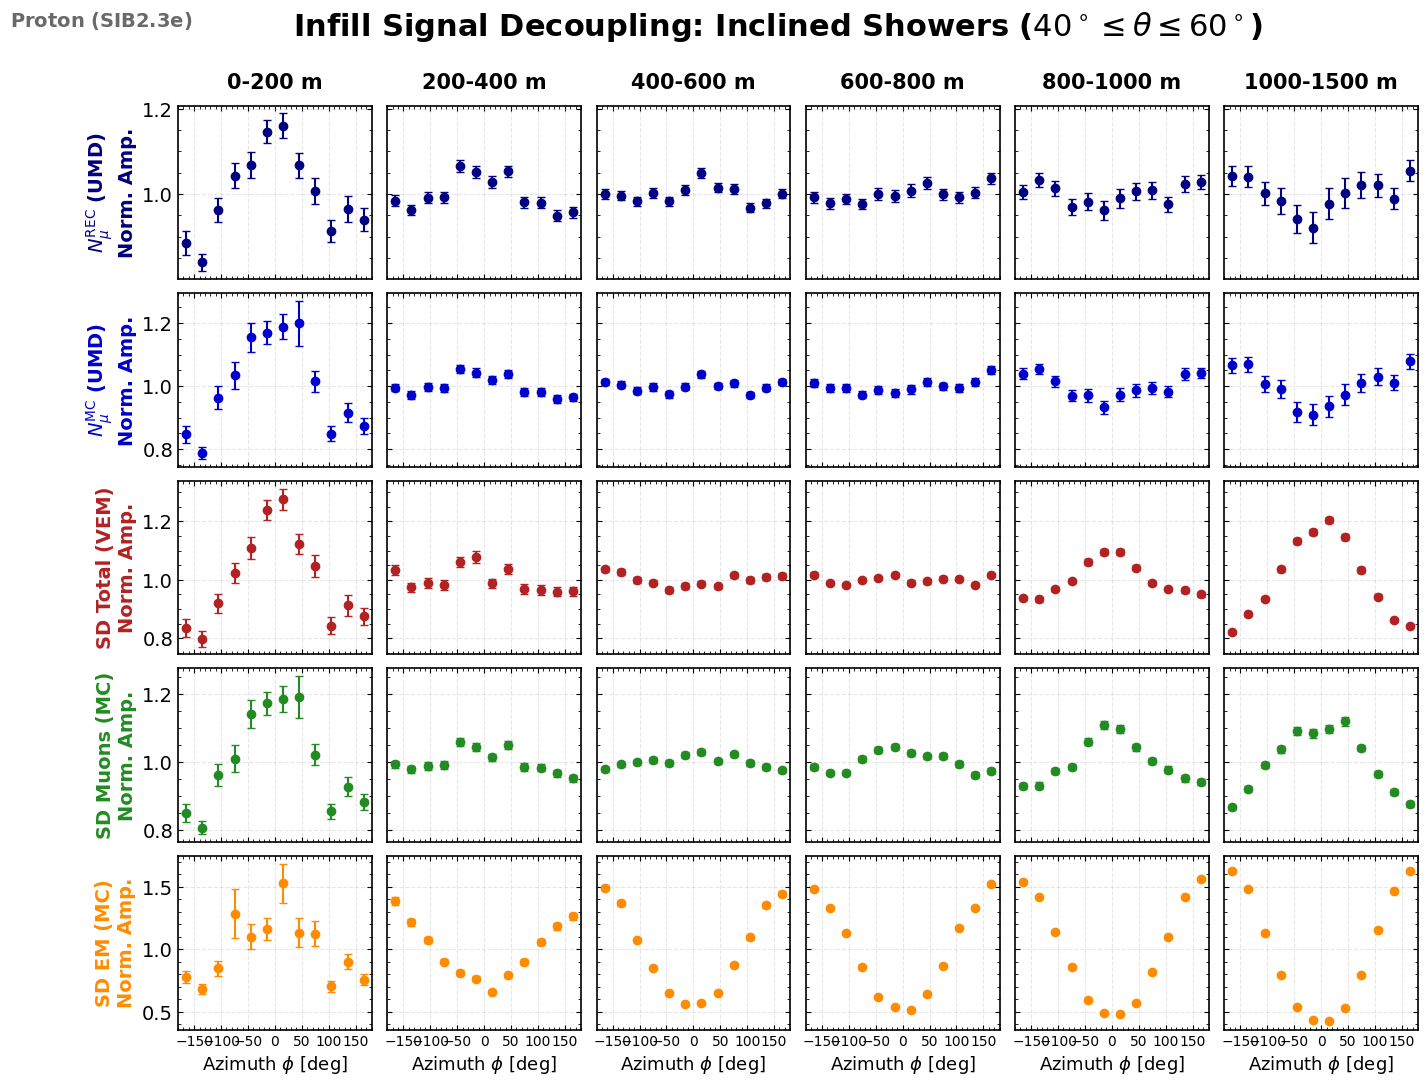

In [3]:
# =========================================================================
# CELDA: PERFILES INFILL (40°-60°) - 5 FILAS (UMD + SD DECOUPLED)
# =========================================================================

# 1. Filtrar Infill y Rango Zenital Inclinado
df_inf = df_guia[(df_guia['counterId'] >= 100000) & 
                 (df_guia['theta_REC'] >= 40) & 
                 (df_guia['theta_REC'] <= 60)].copy()

# 2. Configuración de Bines Radiales (6 columnas)
r_edges = [0, 200, 400, 600, 800, 1000, 1500] 
r_labels = ["0-200 m", "200-400 m", "400-600 m", "600-800 m", "800-1000 m", "1000-1500 m"]
df_inf['r_bin'] = pd.cut(df_inf['r_core'], bins=r_edges, labels=False, include_lowest=True)

# 3. Pre-cálculo de ángulos con Euler Fix (REC y MC)
p_rec = ensure_degrees(df_inf['phi_plane_euler'], 'Euler REC')
df_inf['p_rec_cen'] = (p_rec + 180) % 360 - 180

if 'phi_plane_euler_MC' in df_inf.columns:
    p_mc = ensure_degrees(df_inf['phi_plane_euler_MC'], 'Euler MC')
    df_inf['p_mc_cen'] = (p_mc + 180) % 360 - 180
else:
    df_inf['p_mc_cen'] = df_inf['p_rec_cen']

phi_bin_edges = np.linspace(-180, 180, 13)
phi_centers = (phi_bin_edges[:-1] + phi_bin_edges[1:]) / 2

# 4. Las 5 Filas Definitivas
configs = [
    ('nMuones_REC', r'$N_\mu^{\mathrm{REC}}$ (UMD)', 'navy'), 
    ('nMuones_MC', r'$N_\mu^{\mathrm{MC}}$ (UMD)', 'mediumblue'), 
    ('sdSignal_REC', r'SD Total (VEM)', 'firebrick'),
    ('sd_nMuons_MC', r'SD Muons (MC)', 'forestgreen'),
    ('sd_nEM_MC', r'SD EM (MC)', 'darkorange')
]

# 5. Preparación del Plot (5 Filas x 6 Columnas)
fig, axs = plt.subplots(5, 6, figsize=(16, 12), sharex=True, sharey='row')

for k, (col_name, label, color) in enumerate(configs):
    for j in range(6):
        ax = axs[k, j]
        df_r = df_inf[df_inf['r_bin'] == j].copy()
        
        if col_name not in df_r.columns:
            ax.text(0.5, 0.5, f"No Data", ha='center', va='center', alpha=0.5)
            continue
            
        if df_r.empty or len(df_r.dropna(subset=[col_name])) < 15:
            ax.text(0.5, 0.5, "Baja Est.", ha='center', va='center', alpha=0.5)
            continue

        # Usamos ángulo MC para las variables MC puras, REC para las reconstruidas
        angle_col = 'p_rec_cen' if 'REC' in col_name else 'p_mc_cen'
        df_r['bin_phi'] = pd.cut(df_r[angle_col], bins=phi_bin_edges)
        
        st = df_r.groupby('bin_phi', observed=True)[col_name].agg(['mean','sem']).dropna()
        
        means = st['mean']
        sems = st['sem']
        norm = means.mean()
        
        if norm == 0 or pd.isna(norm): continue
        
        # Ploteo
        ax.errorbar(phi_centers, means/norm, yerr=sems/norm, fmt='o', 
                    color=color, markersize=6, capsize=3, elinewidth=1.5)
        
        # Estética de sub-panel
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim(-180, 180)
        ax.set_xticks([-150, -100, -50, 0, 50, 100, 150])
        
        if k == 0: 
            ax.set_title(r_labels[j], fontsize=15, fontweight='bold', pad=12)
        if k == 4: 
            ax.set_xlabel(r"Azimuth $\phi$ [deg]", fontsize=13)
            ax.tick_params(axis='x', labelsize=10)
        else:
            ax.tick_params(axis='x', labelbottom=False)
            
        if j == 0: 
            ax.set_ylabel(f"{label}\nNorm. Amp.", fontsize=14, fontweight='bold', color=color)

fig.suptitle(r"Infill Signal Decoupling: Inclined Showers ($40^\circ \leq \theta \leq 60^\circ$)", 
             fontsize=22, fontweight='bold', y=0.96)

fig.text(0.02, 0.96, r"$\mathbf{Proton\ (SIB2.3e)}$", fontsize=14, va='top', ha='left', color='dimgray')

plt.subplots_adjust(hspace=0.08, wspace=0.08)
plt.show()